In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             matthews_corrcoef, f1_score)
from sklearn.tree import plot_tree                             
import os
import pickle

In [29]:
df = pd.read_csv("dataset/clean.csv")

X = df.drop(columns=['loan_status'])
y = df['loan_status']

print("--- Target Variable (loan_status) Distribution ---")
print(y.value_counts())
print(f"\nImbalance Ratio (Class 0 : Class 1) -> {(y.value_counts()[0] / y.value_counts()[1]):.2f} : 1")

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

--- Target Variable (loan_status) Distribution ---
loan_status
0    22428
1     6202
Name: count, dtype: int64

Imbalance Ratio (Class 0 : Class 1) -> 3.62 : 1


In [30]:
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [31]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Matthews Correlation Coefficient (MCC): {matthews_corrcoef(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9169
F1 Score (Macro): 0.8642
Matthews Correlation Coefficient (MCC): 0.7434

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      4479
           1       0.92      0.68      0.78      1247

    accuracy                           0.92      5726
   macro avg       0.92      0.83      0.86      5726
weighted avg       0.92      0.92      0.91      5726



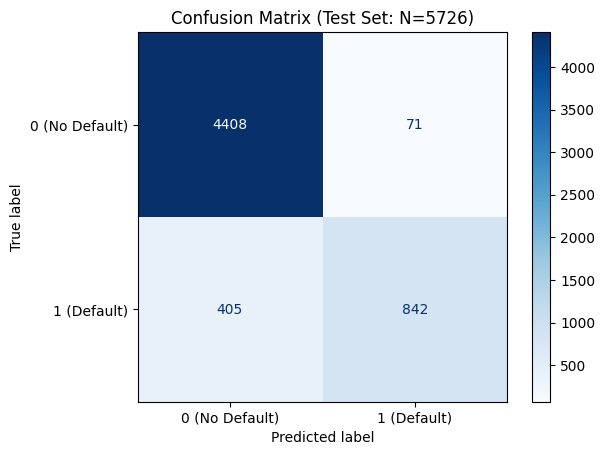

In [32]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0 (No Default)", "1 (Default)"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix (Test Set: N=5726)")
plt.grid(False)
plt.show()

c:\Users\damar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


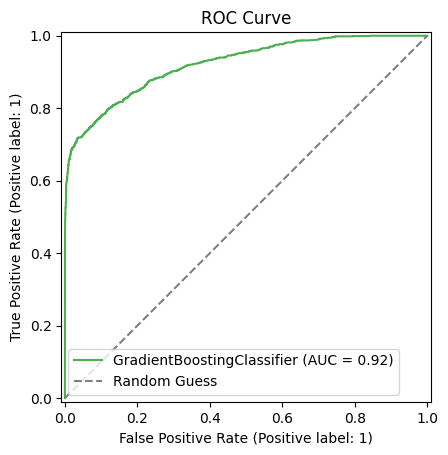

In [33]:
RocCurveDisplay.from_estimator(model, X_test, y_test, color="#4CAF50")
plt.title("ROC Curve")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.legend()
plt.show()

C:\Users\damar\AppData\Local\Temp\ipykernel_30144\3490489218.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


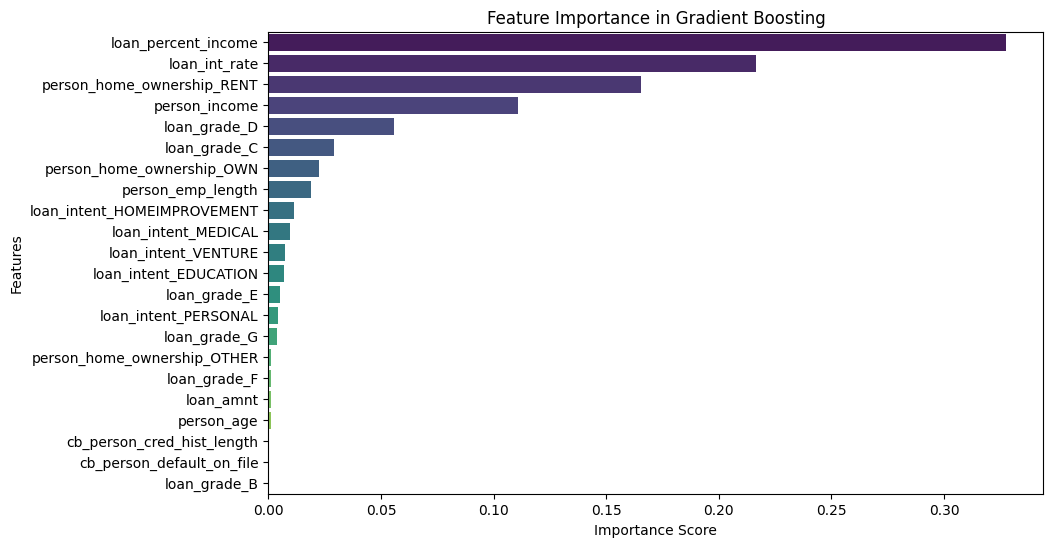

In [34]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.title("Feature Importance in Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

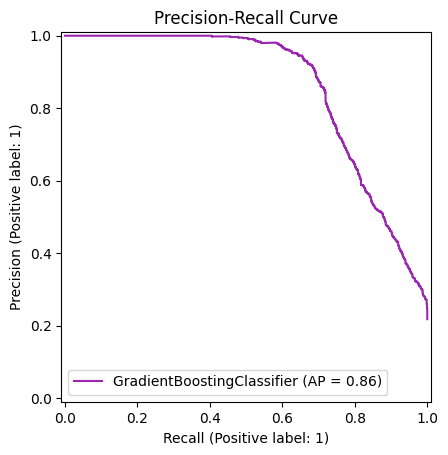

In [35]:
PrecisionRecallDisplay.from_estimator(model, X_test, y_test, color="#9C27B0")
plt.title("Precision-Recall Curve")
plt.show()

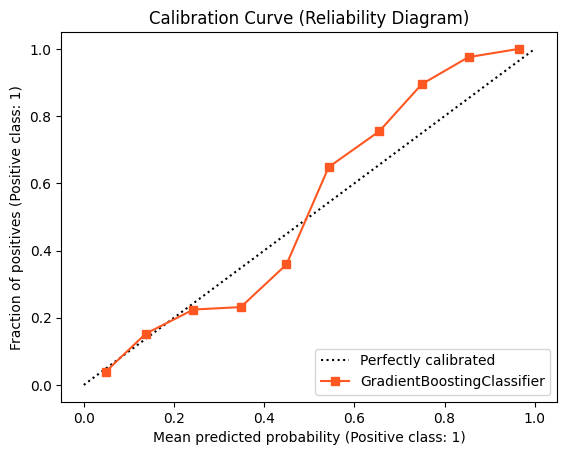

In [36]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, color='#FF5722')
plt.title("Calibration Curve (Reliability Diagram)")
plt.show()

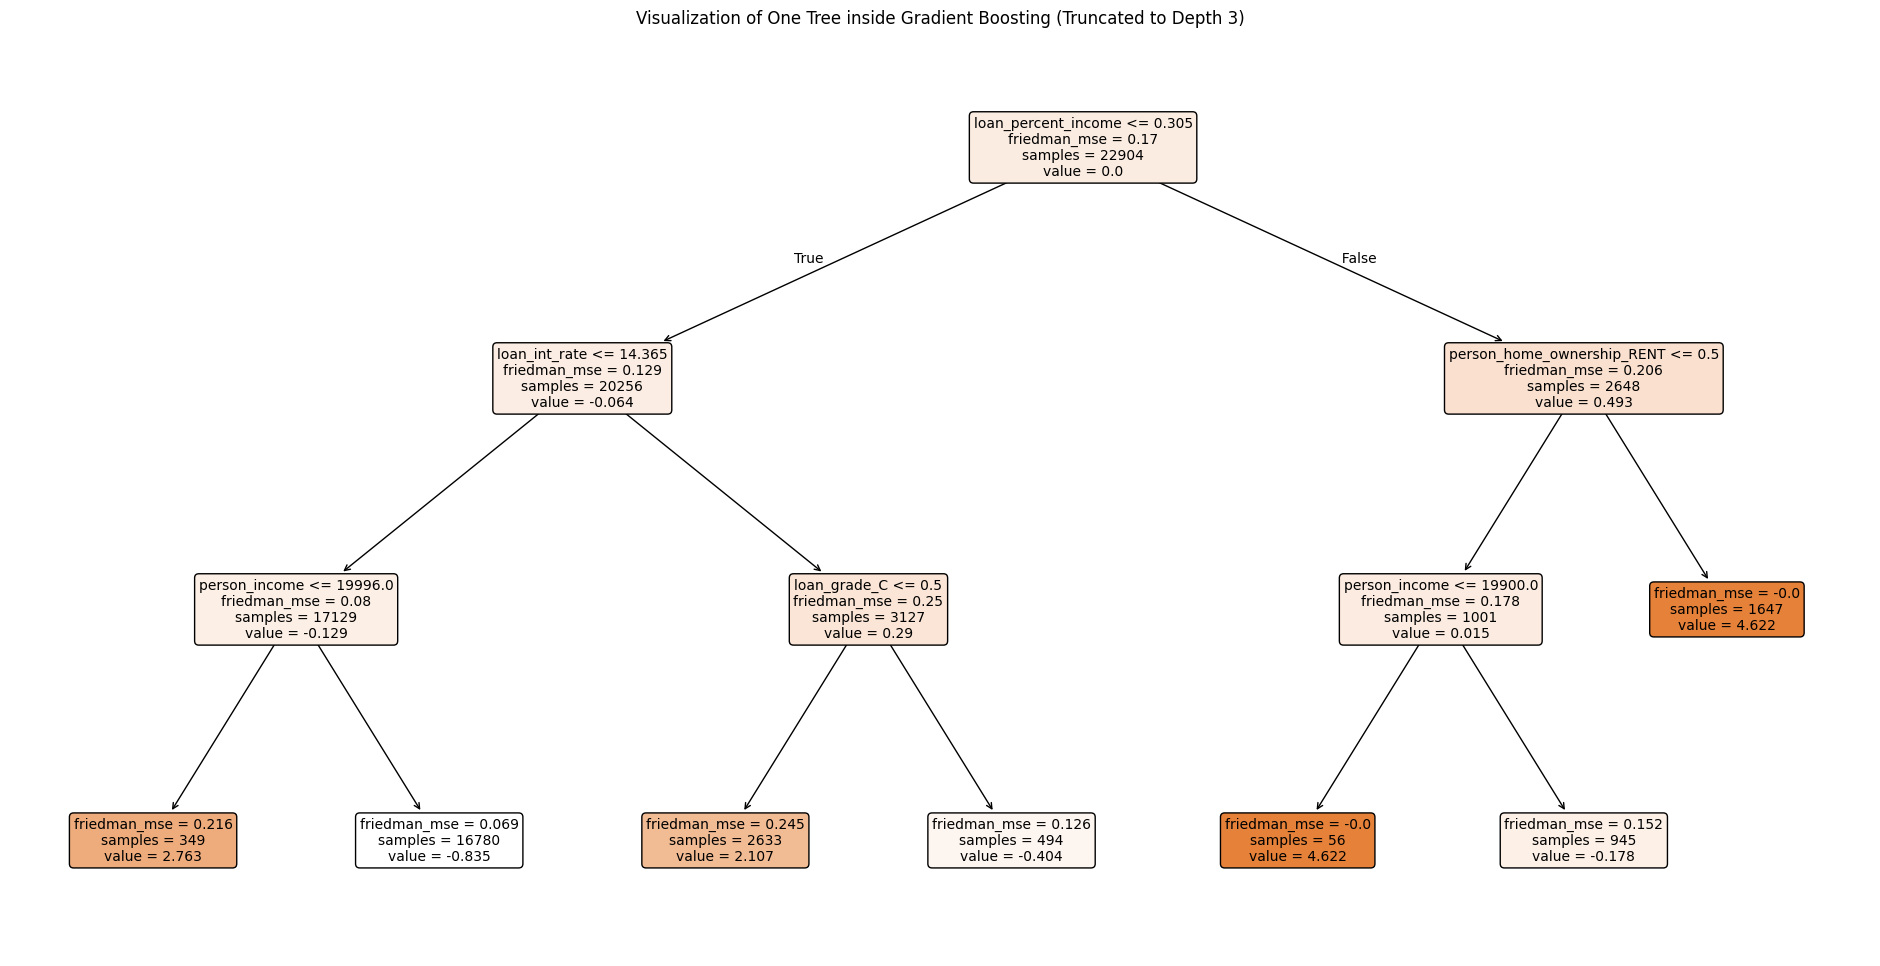

In [37]:
plt.figure(figsize=(24, 12))
first_tree = model.estimators_[0, 0]
plot_tree(first_tree, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          max_depth=3,
          fontsize=10)
plt.title("Visualization of One Tree inside Gradient Boosting (Truncated to Depth 3)")
plt.show()

In [38]:
os.makedirs("model_save", exist_ok=True)
model_path = "model_save/gradient_boosting.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model successfully saved to {model_path}")

Model successfully saved to model_save/gradient_boosting.pkl
